In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torch
import torch.nn as nn
import cv2
from torchvision.datasets import ImageFolder

In [4]:
print(os.getcwd())
file_path = "../data/archive/"
dataframe = pd.read_csv(file_path+"Test.csv")
dataframe.head()

c:\Users\rahul\OneDrive\Desktop\Rahul\Study\Projects\traffic-sign-recognition\notebooks


,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,53,54,6,5,48,49,16,Test/00000.png
1,42,45,5,5,36,40,1,Test/00001.png
2,48,52,6,6,43,47,38,Test/00002.png
3,27,29,5,5,22,24,33,Test/00003.png
4,60,57,5,5,55,52,11,Test/00004.png


In [5]:
dataframe.shape

(12630, 8)

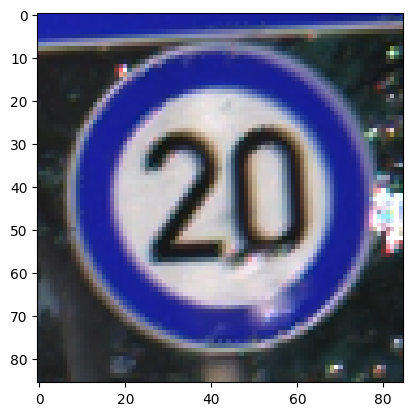

In [6]:
image = cv2.imread(r"C:\Users\rahul\OneDrive\Desktop\Rahul\Study\Projects\traffic-sign-recognition\data\archive\Train\0\00000_00000_00025.png")
image.shape
plt.imshow(image)

Using Imagefolder for labeling

In [7]:
# applying transformations
transform_pipeline = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])


# train dataset and loader
train_dataset = ImageFolder(file_path+"Train",
                            transform=transform_pipeline)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
type(train_dataset)
type(train_loader)

torch.utils.data.dataloader.DataLoader

In [8]:
print(train_dataset.class_to_idx)

{'0': 0, '1': 1, '10': 2, '11': 3, '12': 4, '13': 5, '14': 6, '15': 7, '16': 8, '17': 9, '18': 10, '19': 11, '2': 12, '20': 13, '21': 14, '22': 15, '23': 16, '24': 17, '25': 18, '26': 19, '27': 20, '28': 21, '29': 22, '3': 23, '30': 24, '31': 25, '32': 26, '33': 27, '34': 28, '35': 29, '36': 30, '37': 31, '38': 32, '39': 33, '4': 34, '40': 35, '41': 36, '42': 37, '5': 38, '6': 39, '7': 40, '8': 41, '9': 42}


Dataset for test

In [9]:
class TrafficSignDataset(Dataset):
    def __init__(self, file_path, csv_path, transform=None):
        super().__init__()
        self.file_path = file_path
        self.transform = transform
        self.csv_data = pd.read_csv(csv_path)

    def __len__(self):
        return len(os.listdir(self.file_path+"Test"))
    
    def __getitem__(self, idx):
        img_name = os.path.basename(self.csv_data.iloc[idx, -1])
        img_path = os.path.join(self.file_path, img_name)
        label = int(self.csv_data.iloc[idx, -2])
        if self.transform:
            image = self.transform(image)
        return image, label

test_dataset = TrafficSignDataset(file_path+"Test",file_path+"Test.csv", transform=transform_pipeline)
test_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)


CNN model

In [10]:
class CNNModel(nn.Module):
    def __init__(self, num_classes=43):
        super(CNNModel, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

Hyperparameters

In [11]:
learning_rate = 0.001
num_epochs = 10
batch_size = 32

Model instance

In [12]:
model = CNNModel(num_classes=43)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(model)

CNNModel(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=43, bias=True)
  )
)


Training loop

In [13]:
# training loop
train = False

if train:
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * images.size(0)
        epoch_loss = running_loss / len(train_loader.dataset)
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}")
else:
    model_path = "../models/traffic_sign_cnn.pth"
    model.load_state_dict(torch.load(model_path))
    model.eval()

In [14]:
model_path = "../models/traffic_sign_cnn.pth"
torch.save(model.state_dict(), model_path)

Model evaluation

In [15]:
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
print(f"Test Accuracy: {100 * correct / total:.2f}%")


Test Accuracy: 99.91%
